In [1]:
import os

import cartopy.crs as ccrs
import cmcrameri as cmc  # noqa: F401
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import yaml
from tqdm.auto import tqdm
from unseen_awg.plotting_utils import map_plot_without_frame_with_bounds

In [2]:
mpl.rc_file("../../matplotlibrc")

In [3]:
with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

In [4]:
z = xr.open_dataset(
    os.path.join(
        paths["dir_preprocessed_datasets"],
        "preprocessed_circulation_reforecasts",
        "combined_5e06172f.zarr",
    ),
    decode_timedelta=True,
)["geopotential_height"].isel(init_time=-5, ensemble_member=0, lead_time=2)
doy = (z.init_time + z.lead_time).dt.dayofyear

/tmp/ipykernel_1264252/1981068528.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


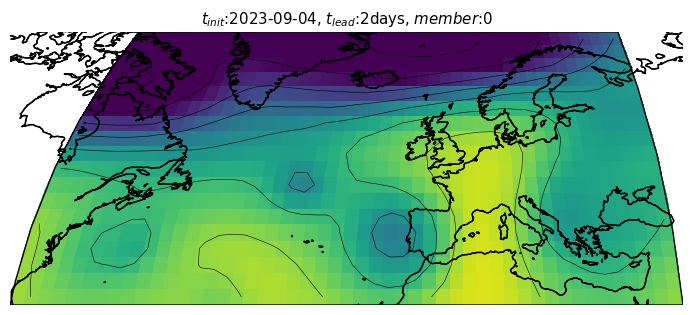

In [5]:
fig, axes = plt.subplots(
    1,
    1,
    subplot_kw=dict(projection=ccrs.Robinson()),
    figsize=(7, 5),
)

# cmap = mpl.colormaps.get_cmap("copper")
# cmap.set_under(alpha=0)
# cmap.set_over(alpha=1)

it = z.init_time.squeeze().values.astype("datetime64[ns]")
lt = z.lead_time.squeeze().values.astype("timedelta64[ns]")
em = z.ensemble_member.squeeze().values


map_plot_without_frame_with_bounds(
    ax=axes, da=z, add_colorbar=False, vmin=540, vmax=600
)


z.plot.contour(ax=axes, transform=ccrs.PlateCarree(), colors="black", linewidths=0.4)

axes.set_title(
    r"$t_{init}$:"
    + np.datetime_as_string((it + lt).squeeze(), unit="D")
    + r", $t_{lead}$:"
    + f"{int(lt / np.timedelta64(1, 'D'))}"
    + r"days, $member$:"
    + f"{em}"
)


axes.coastlines()

plt.tight_layout()

plt.savefig(os.path.join(paths["dir_images"], "sample_pattern.jpg"), dpi=300)

In [6]:
t2m = xr.open_zarr(
    os.path.join(
        paths["dir_preprocessed_datasets"],
        "preprocessed_impact_variables_reforecasts",
        "rechunk_combined-corrected_facc0e91_7d1d3d97_884a804a_3f7e331d.zarr",  # "rechunk_combined_7d1d3d97.zarr",
    )
)[["t2m"]]
t2m = t2m.assign_coords(
    valid_time=t2m.init_time
    + t2m.lead_time
    + np.timedelta64(0, "D") * t2m.ensemble_member
)  # to get ds_re.ensemble_member dimension too

t2m_era5 = xr.open_zarr(
    os.path.join(
        paths["dir_preprocessed_datasets"],
        "preprocessed_impact_variables_era5",
        "rechunk_combined_facc0e91.zarr",
    )
)[["t2m"]]

t2m_era5["lead_time"] = t2m_era5.lead_time + t2m_era5.init_time.data
t2m_era5 = t2m_era5.rename({"lead_time": "valid_time"})

slice_reforecast_time_extent = slice(
    t2m.valid_time.min().data, t2m.valid_time.max().data
)

In [7]:
t2m_era5

<xarray.Dataset> Size: 805MB
Dimensions:          (ensemble_member: 1, init_time: 1, valid_time: 7670,
                      latitude: 105, longitude: 125)
Coordinates:
  * ensemble_member  (ensemble_member) int64 8B 0
  * init_time        (init_time) datetime64[ns] 8B 2003-01-01
  * valid_time       (valid_time) datetime64[ns] 61kB 2003-01-01 ... 2023-12-31
  * latitude         (latitude) float64 840B 71.8 71.4 71.0 ... 31.0 30.6 30.2
  * longitude        (longitude) float64 1kB -9.8 -9.4 -9.0 ... 39.0 39.4 39.8
Data variables:
    t2m              (ensemble_member, init_time, valid_time, latitude, longitude) float64 805MB dask.array<chunksize=(1, 1, 7670, 105, 1), meta=np.ndarray>

In [8]:
xr.open_zarr(
    os.path.join(
        paths["dir_preprocessed_datasets"],
        "preprocessed_impact_variables_era5",
        "rechunk_combined_facc0e91.zarr",
    )
)[["t2m"]].isel(
    ensemble_member=0, init_time=0, lead_time=0, latitude=2, longitude=0
).load()

<xarray.Dataset> Size: 48B
Dimensions:          ()
Coordinates:
    ensemble_member  int64 8B 0
    init_time        datetime64[ns] 8B 2003-01-01
    latitude         float64 8B 71.0
    lead_time        timedelta64[ns] 8B 00:00:00
    longitude        float64 8B -9.8
Data variables:
    t2m              float64 8B 0.1405

In [9]:
# how many years of samples do we roughly have in the reforecast dataset?
(len(t2m.init_time) * len(t2m.lead_time) * len(t2m.ensemble_member)) / 365

3548.931506849315

In [10]:
t2m_era_grouped = t2m_era5.sel(valid_time=slice_reforecast_time_extent).groupby(
    "valid_time.dayofyear"
)

clim_era5_mean = t2m_era_grouped.mean().compute()
clim_era5_median = t2m_era_grouped.median().compute()
clim_era5_max = t2m_era_grouped.max().compute()
clim_era5_min = t2m_era_grouped.min().compute()

In [11]:
t2m_era_full_grouped = t2m_era5.groupby("valid_time.dayofyear")

clim_era5_full_mean = t2m_era_full_grouped.mean().compute()
clim_era5_full_median = t2m_era_full_grouped.median().compute()
clim_era5_full_max = t2m_era_full_grouped.max().compute()
clim_era5_full_min = t2m_era_full_grouped.min().compute()

In [12]:
os.makedirs(os.path.join(paths["dir_results"], "plots_min_max"), exist_ok=True)

In [13]:
clim_era5_min.to_netcdf(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_slice_min.nc")
)
clim_era5_max.to_netcdf(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_slice_max.nc")
)
clim_era5_mean.to_netcdf(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_slice_mean.nc")
)
clim_era5_median.to_netcdf(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_slice_median.nc")
)

clim_era5_full_min.to_netcdf(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_full_slice_min.nc")
)
clim_era5_full_max.to_netcdf(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_full_slice_max.nc")
)
clim_era5_full_mean.to_netcdf(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_full_slice_mean.nc")
)
clim_era5_full_median.to_netcdf(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_full_slice_median.nc")
)

In [14]:
clim_era5_max = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_slice_max.nc")
)
clim_era5_mean = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_slice_mean.nc")
)
clim_era5_median = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_slice_median.nc")
)
clim_era5_min = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_slice_min.nc")
)

clim_era5_full_max = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_full_slice_max.nc")
)
clim_era5_full_mean = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_full_slice_mean.nc")
)
clim_era5_full_median = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_full_slice_median.nc")
)
clim_era5_full_min = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_era_full_slice_min.nc")
)

In [15]:
def get_ds_new(ds_old):
    return xr.Dataset(
        {
            var: (
                ("dayofyear", "latitude", "longitude"),
                np.full(
                    (
                        len(ds_old.dayofyear),
                        len(ds_old.latitude),
                        len(ds_old.longitude),
                    ),
                    fill_value=np.nan,
                ),
            )
            for var in ds_old.data_vars
        },
        coords=ds_old.coords,
    )


# set up sth where we can store the results.
t2m_clim_min = get_ds_new(
    t2m.isel(init_time=0, ensemble_member=0, lead_time=0)
    .drop_vars(("init_time", "ensemble_member", "valid_time", "lead_time"))
    .expand_dims({"dayofyear": np.arange(1, 367)})
)
t2m_clim_max = get_ds_new(
    t2m.isel(init_time=0, ensemble_member=0, lead_time=0)
    .drop_vars(("init_time", "ensemble_member", "valid_time", "lead_time"))
    .expand_dims({"dayofyear": np.arange(1, 367)})
)
t2m_clim_mean = get_ds_new(
    t2m.isel(init_time=0, ensemble_member=0, lead_time=0)
    .drop_vars(("init_time", "ensemble_member", "valid_time", "lead_time"))
    .expand_dims({"dayofyear": np.arange(1, 367)})
)
t2m_clim_median = get_ds_new(
    t2m.isel(init_time=0, ensemble_member=0, lead_time=0)
    .drop_vars(("init_time", "ensemble_member", "valid_time", "lead_time"))
    .expand_dims({"dayofyear": np.arange(1, 367)})
)

In [16]:
dims = ("dayofyear", "latitude", "longitude")
coords = {
    "dayofyear": np.arange(1, 367),
    "latitude": t2m.latitude,
    "longitude": t2m.longitude,
}

ds_clim_reforecasts = xr.Dataset()


for lon in tqdm(t2m.longitude, leave=False):
    gpd = t2m.sel(longitude=lon).compute().groupby("valid_time.dayofyear")
    t2m_clim_min.loc[dict(longitude=lon)] = gpd.min()
    t2m_clim_max.loc[dict(longitude=lon)] = gpd.max()
    t2m_clim_mean.loc[dict(longitude=lon)] = gpd.mean()
    t2m_clim_median.loc[dict(longitude=lon)] = gpd.median()


t2m_clim_max.to_netcdf(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_ref_max.nc")
)
t2m_clim_mean.to_netcdf(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_ref_mean.nc")
)
t2m_clim_median.to_netcdf(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_ref_median.nc")
)
t2m_clim_min.to_netcdf(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_ref_min.nc")
)

  0%|          | 0/125 [00:00<?, ?it/s]

In [17]:
t2m_clim_max = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_ref_max.nc")
)
t2m_clim_mean = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_ref_mean.nc")
)
t2m_clim_median = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_ref_median.nc")
)
t2m_clim_min = xr.open_dataset(
    os.path.join(paths["dir_results"], "plots_min_max", "clim_ref_min.nc")
)

In [18]:
coords_vienna = {"latitude": 48.21, "longitude": 16.37}
coords_leipzig = {"latitude": 51.340199, "longitude": 12.360103}

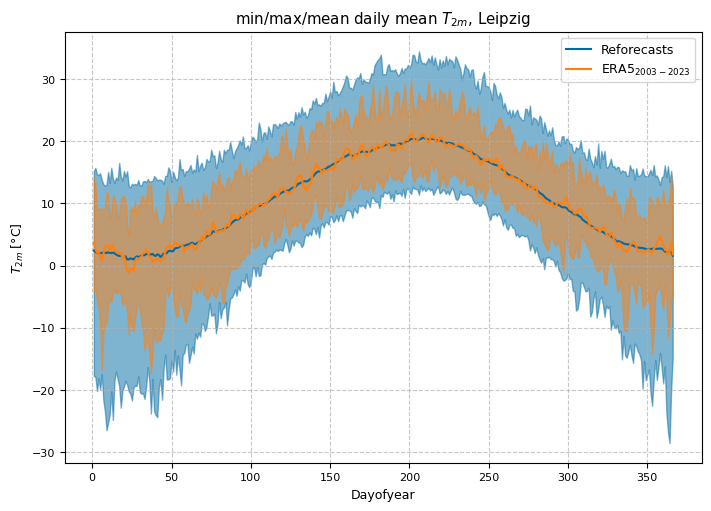

In [19]:
plt.figure(figsize=(7, 5))
t2m_clim_mean["t2m"].sel(coords_leipzig, method="nearest").plot(
    color="C0", label="Reforecasts"
)
plt.fill_between(
    t2m_clim_mean["t2m"].dayofyear,
    t2m_clim_min["t2m"].sel(coords_leipzig, method="nearest"),
    t2m_clim_max["t2m"].sel(coords_leipzig, method="nearest"),
    alpha=0.5,
    color="C0",
)

clim_era5_mean["t2m"].sel(coords_leipzig, method="nearest").plot(
    color="C1", label=r"$\text{ERA5}_{2003-2023}$"
)
plt.fill_between(
    clim_era5_min["t2m"].dayofyear,
    clim_era5_min["t2m"].sel(coords_leipzig, method="nearest").squeeze(),
    clim_era5_max["t2m"].sel(coords_leipzig, method="nearest").squeeze(),
    alpha=0.5,
    color="C1",
)

# clim_era5_full_mean["t2m"].sel(coords_leipzig, method="nearest").plot(
#     color="C2", label="ERA5"
# )
# plt.fill_between(
#     clim_era5_full_min["t2m"].dayofyear,
#     clim_era5_full_min["t2m"].sel(coords_leipzig, method="nearest").squeeze(),
#     clim_era5_full_max["t2m"].sel(coords_leipzig, method="nearest").squeeze(),
#     alpha=0.5,
#     color="C2",
# )
plt.title(r"min/max/mean daily mean $T_{2m}$, Leipzig")
plt.ylabel(r"$T_{2m}$ [°C]")
plt.xlabel("Dayofyear")
plt.legend()
plt.savefig(os.path.join(paths["dir_images"], "climatology_leipzig.jpg"), dpi=300)

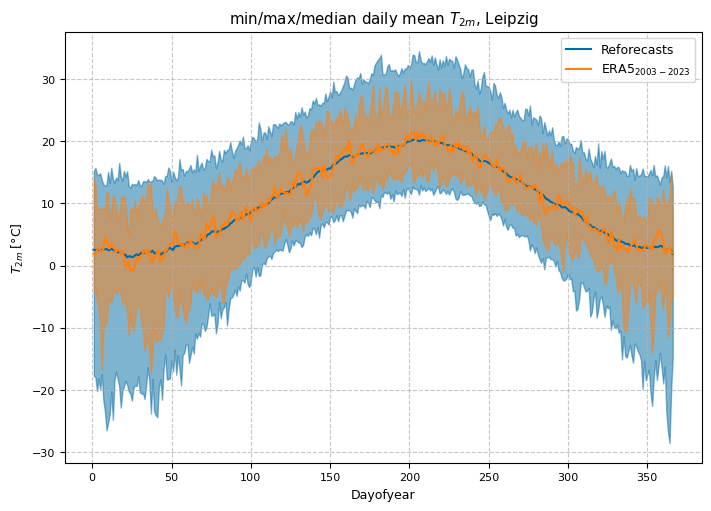

In [20]:
plt.figure(figsize=(7, 5))
t2m_clim_median["t2m"].sel(coords_leipzig, method="nearest").plot(
    color="C0", label="Reforecasts"
)
plt.fill_between(
    t2m_clim_median["t2m"].dayofyear,
    t2m_clim_min["t2m"].sel(coords_leipzig, method="nearest"),
    t2m_clim_max["t2m"].sel(coords_leipzig, method="nearest"),
    alpha=0.5,
    color="C0",
)

clim_era5_median["t2m"].sel(coords_leipzig, method="nearest").plot(
    color="C1", label=r"$\text{ERA5}_{2003-2023}$"
)
plt.fill_between(
    clim_era5_min["t2m"].dayofyear,
    clim_era5_min["t2m"].sel(coords_leipzig, method="nearest").squeeze(),
    clim_era5_max["t2m"].sel(coords_leipzig, method="nearest").squeeze(),
    alpha=0.5,
    color="C1",
)

# clim_era5_full_median["t2m"].sel(coords_leipzig, method="nearest").plot(
#     color="C2", label="ERA5"
# )
# plt.fill_between(
#     clim_era5_full_min["t2m"].dayofyear,
#     clim_era5_full_min["t2m"].sel(coords_leipzig, method="nearest").squeeze(),
#     clim_era5_full_max["t2m"].sel(coords_leipzig, method="nearest").squeeze(),
#     alpha=0.5,
#     color="C2",
# )
plt.title(r"min/max/median daily mean $T_{2m}$, Leipzig")
plt.ylabel(r"$T_{2m}$ [°C]")
plt.xlabel("Dayofyear")
plt.legend()
plt.savefig(
    os.path.join(paths["dir_images"], "climatology_leipzig_median.jpg"), dpi=300
)